# A/B Backtest Viewer

Auto-discovers latest A/B pair under `eval_results/backtest/ab_pairs`.

Focus:
- config differences (`A` vs `B`)
- summary metric comparison + `B-A` deltas
- normalized equity comparison


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

def _resolve_backtest_root() -> Path:
    for c in (Path('eval_results/backtest'), Path('../eval_results/backtest')):
        if c.exists():
            return c
    return Path('eval_results/backtest')

def _is_valid_pair(path: Path) -> bool:
    return (
        path.is_dir()
        and (path / 'comparison.json').exists()
        and (path / 'config_a.json').exists()
        and (path / 'config_b.json').exists()
        and (path / 'run_a' / 'equity_curve.csv').exists()
        and (path / 'run_b' / 'equity_curve.csv').exists()
    )

BACKTEST_ROOT = _resolve_backtest_root()
PAIR_ROOT = BACKTEST_ROOT / 'ab_pairs'
assert PAIR_ROOT.exists(), f'No ab_pairs directory found: {PAIR_ROOT.resolve()}'
PAIRS = sorted([p for p in PAIR_ROOT.iterdir() if _is_valid_pair(p)], key=lambda p: p.stat().st_mtime, reverse=True)
assert PAIRS, f'No valid A/B pair runs found under: {PAIR_ROOT.resolve()}'

display(pd.DataFrame([
    {'rank': i + 1, 'pair_dir': p.name, 'modified_at': pd.to_datetime(p.stat().st_mtime, unit='s')}
    for i, p in enumerate(PAIRS[:12])
]))


,rank,pair_dir,modified_at
0,1,20260426T215220Z_mom_12m_skip_1m_promotion,2026-04-26 21:52:57.843085289


In [2]:
# Defaults to latest pair. Uncomment to pin.
PAIR_DIR = PAIRS[0]
# PAIR_DIR = PAIR_ROOT / '20260301T200856Z_single_alpha_sector_mom_top2_vs_baseline'

cmp_payload = json.loads((PAIR_DIR / 'comparison.json').read_text())
cfg_a = json.loads((PAIR_DIR / 'config_a.json').read_text())
cfg_b = json.loads((PAIR_DIR / 'config_b.json').read_text())

label_a = cmp_payload.get('labels', {}).get('a', 'A')
label_b = cmp_payload.get('labels', {}).get('b', 'B')

def _resolve_run_dir(raw_dir: str | None, default_dir: Path) -> Path:
    p = Path(raw_dir) if raw_dir else default_dir
    if p.exists():
        return p
    if not p.is_absolute():
        repo_relative = Path('..') / p
        if repo_relative.exists():
            return repo_relative
    return default_dir

run_a_dir = _resolve_run_dir(cmp_payload.get('run_a', {}).get('dir'), PAIR_DIR / 'run_a')
run_b_dir = _resolve_run_dir(cmp_payload.get('run_b', {}).get('dir'), PAIR_DIR / 'run_b')

print('Pair:', PAIR_DIR.name)
print('Requested window:', cmp_payload.get('requested_window'))
print('Actual window:', cmp_payload.get('actual_window'))
print('Run A:', label_a, run_a_dir)
print('Run B:', label_b, run_b_dir)


Pair: 20260426T215220Z_mom_12m_skip_1m_promotion
Requested window: {'start': '2021-05-23', 'end': '2026-02-28'}
Actual window: {'start': '2021-05-23', 'end': '2026-02-28'}
Run A: old_default_no_skip ../eval_results/backtest/ab_pairs/20260426T215220Z_mom_12m_skip_1m_promotion/run_a
Run B: new_default_with_skip ../eval_results/backtest/ab_pairs/20260426T215220Z_mom_12m_skip_1m_promotion/run_b


In [3]:
def _config_diff(a: dict, b: dict) -> pd.DataFrame:
    rows = []
    for k in sorted(set(a.keys()) | set(b.keys())):
        if a.get(k) != b.get(k):
            rows.append({'key': k, 'A_value': a.get(k), 'B_value': b.get(k)})
    return pd.DataFrame(rows)

cfg_diff = _config_diff(cfg_a, cfg_b)
print('Changed settings:', len(cfg_diff))
display(cfg_diff)


Changed settings: 3


,key,A_value,B_value
0,alpha_signal_registry,"[{'type': 'momentum', 'name': 'mom_1m', 'windo...","[{'type': 'momentum', 'name': 'mom_1m', 'windo..."
1,alpha_signals,"[mom_1m, mom_3m, mom_6m, mom_12m, trend_12m_1m...","[mom_1m, mom_3m, mom_6m, mom_12m, mom_12m_skip..."
2,backtest_output_dir,eval_results/backtest/ab_pairs/20260426T215220...,eval_results/backtest/ab_pairs/20260426T215220...


In [4]:
summary_rows = []
for label, key in [(label_a, 'run_a'), (label_b, 'run_b')]:
    s = cmp_payload.get(key, {}).get('summary', {})
    summary_rows.append({'label': label, **s})
summary_df = pd.DataFrame(summary_rows).set_index('label')
display(summary_df)

delta_df = pd.DataFrame([cmp_payload.get('delta_b_minus_a', {})], index=[f'{label_b}_minus_{label_a}'])
display(delta_df)


,total_return,cagr,sharpe,max_drawdown,tracking_error,realized_active_information_ratio,average_transfer_coefficient,average_transfer_coefficient_legacy_proxy,average_executed_turnover,average_raw_turnover,average_turnover_constraint_drag,average_ic
label,,,,,,,,,,,,
old_default_no_skip,1.746321,0.301538,1.269317,-0.146338,0.126846,1.075623,0.373672,0.527888,0.527612,0.854206,0.326594,0.020212
new_default_with_skip,1.884018,0.318255,1.306677,-0.143252,0.130653,1.153694,0.371336,0.534325,0.521947,0.836184,0.314236,0.019510


,total_return,cagr,sharpe,max_drawdown,tracking_error,realized_active_information_ratio,average_transfer_coefficient,average_transfer_coefficient_legacy_proxy,average_executed_turnover,average_raw_turnover,average_turnover_constraint_drag,average_ic
new_default_with_skip_minus_old_default_no_skip,0.137697,0.016717,0.03736,0.003086,0.003807,0.078072,-0.002336,0.006437,-0.005665,-0.018022,-0.012358,-0.000702


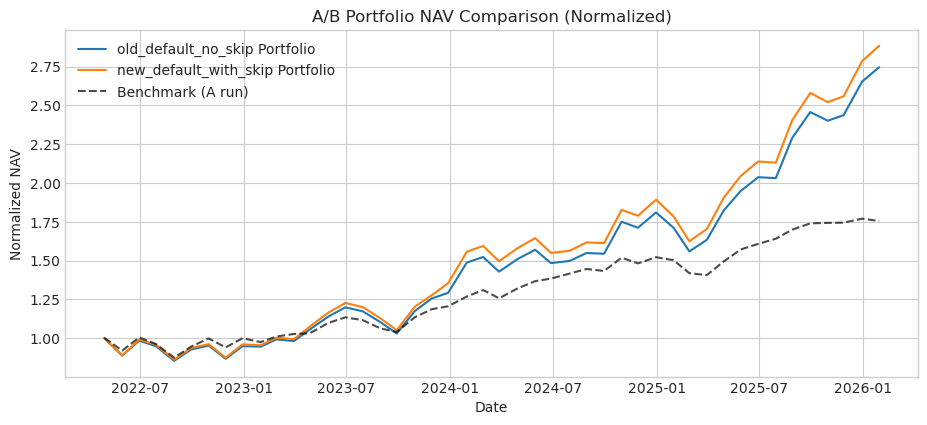

In [5]:
eq_a = pd.read_csv(run_a_dir / 'equity_curve.csv')
eq_b = pd.read_csv(run_b_dir / 'equity_curve.csv')
for eq in (eq_a, eq_b):
    eq['trade_date'] = pd.to_datetime(eq['trade_date'])
    eq['portfolio_nav_norm'] = eq['nav'] / float(eq['nav'].iloc[0])
    eq['benchmark_nav_norm'] = (1.0 + pd.to_numeric(eq['benchmark_return'], errors='coerce').fillna(0.0)).cumprod()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(eq_a['trade_date'], eq_a['portfolio_nav_norm'], label=f'{label_a} Portfolio')
ax.plot(eq_b['trade_date'], eq_b['portfolio_nav_norm'], label=f'{label_b} Portfolio')
ax.plot(eq_a['trade_date'], eq_a['benchmark_nav_norm'], label='Benchmark (A run)', linestyle='--', color='black', alpha=0.7)
ax.set_title('A/B Portfolio NAV Comparison (Normalized)')
ax.set_xlabel('Date')
ax.set_ylabel('Normalized NAV')
ax.legend()
plt.show()


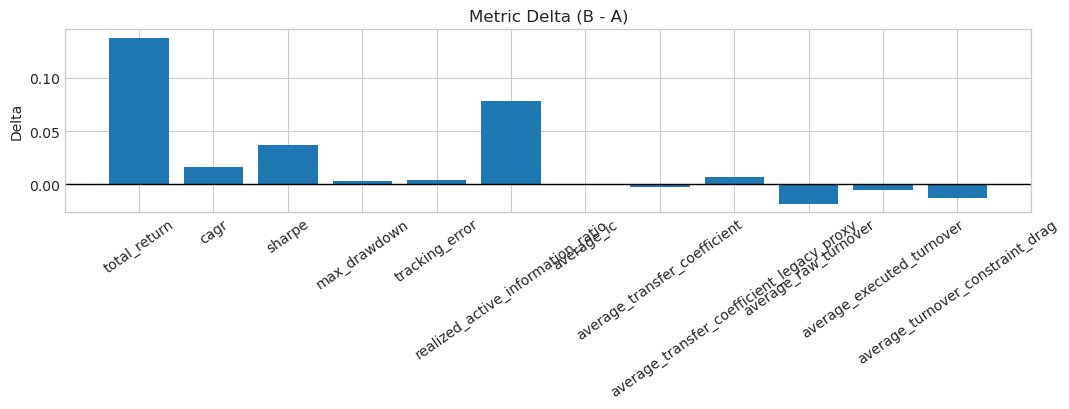

In [6]:
metrics = [
    'total_return', 'cagr', 'sharpe', 'max_drawdown',
    'tracking_error', 'realized_active_information_ratio', 'average_ic',
    'average_transfer_coefficient', 'average_transfer_coefficient_legacy_proxy',
    'average_raw_turnover', 'average_executed_turnover', 'average_turnover_constraint_drag'
]
delta = cmp_payload.get('delta_b_minus_a', {})
plot_df = pd.DataFrame({'metric': metrics, 'delta_b_minus_a': [delta.get(m) for m in metrics]}).dropna()

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.bar(plot_df['metric'], plot_df['delta_b_minus_a'])
ax.axhline(0.0, color='black', linewidth=1)
ax.set_title('Metric Delta (B - A)')
ax.set_ylabel('Delta')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()
